<a href="https://colab.research.google.com/github/verakimoo/2026-1-Project/blob/main/G-S_%EB%B2%95%EC%B9%99_%EA%B8%B0%EB%B0%98_PINN_%EB%AA%A8%EB%8D%B8_%EA%B5%AC%EC%B6%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

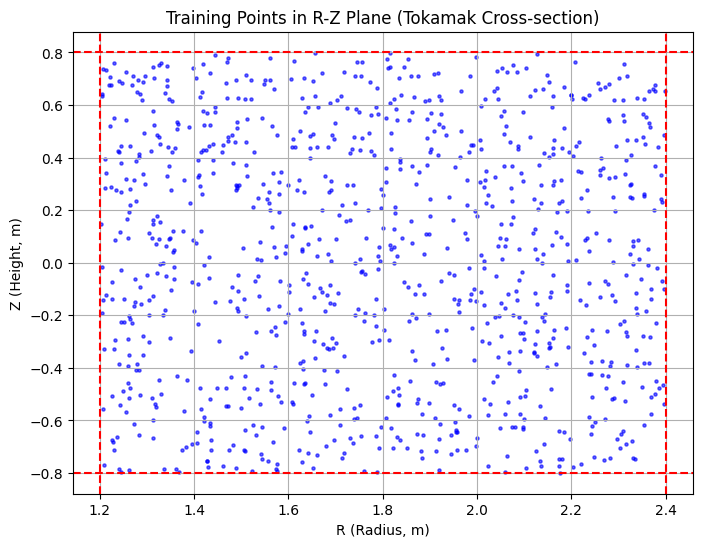

In [1]:
import torch
import matplotlib.pyplot as plt

# 1. 좌표계 범위 설정 (우리의 도화지 크기)
R_min, R_max = 1.2, 2.4
Z_min, Z_max = -0.8, 0.8

# 2. 1000개의 무작위 학습용 점(Point) 생성
num_points = 1000
R_coords = torch.empty(num_points, 1).uniform_(R_min, R_max)
Z_coords = torch.empty(num_points, 1).uniform_(Z_min, Z_max)

# 3. 시각화 (도화지에 점이 잘 찍혔나 확인)
plt.figure(figsize=(8, 6))
plt.scatter(R_coords.numpy(), Z_coords.numpy(), s=5, alpha=0.6, color='blue')
plt.title("Training Points in R-Z Plane (Tokamak Cross-section)")
plt.xlabel("R (Radius, m)")
plt.ylabel("Z (Height, m)")
plt.grid(True)
plt.axvline(R_min, color='red', linestyle='--')
plt.axvline(R_max, color='red', linestyle='--')
plt.axhline(Z_min, color='red', linestyle='--')
plt.axhline(Z_max, color='red', linestyle='--')
plt.show()

In [2]:
# 논문에서 말한 '미분 값 또한 훈련'하는 핵심 로직 (예시)
def compute_ge_loss(model, r, z):
    r.requires_grad = True
    z.requires_grad = True

    psi = model(r, z) # 신경망 출력

    # 1계 미분: d_psi/dr, d_psi/dz
    d_psi = torch.autograd.grad(psi, [r, z], grad_outputs=torch.ones_like(psi), create_graph=True)
    psi_r, psi_z = d_psi[0], d_psi[1]

    # 2계 미분: d2_psi/dr2, d2_psi/dz2 (G-S 식의 델 스타 연산자에 필요)
    psi_rr = torch.autograd.grad(psi_r, r, grad_outputs=torch.ones_like(psi_r), create_graph=True)[0]
    psi_zz = torch.autograd.grad(psi_z, z, grad_outputs=torch.ones_like(psi_z), create_graph=True)[0]

    # 여기에 G-S 식의 나머지 항(압력, 전류 등)을 더해 Loss를 만듭니다.
    return psi_rr, psi_zz # 이것이 0에 가까워지도록 훈련시키는 것임

모델 구조:
PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=40, bias=True)
    (1): Tanh()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): Tanh()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): Tanh()
    (6): Linear(in_features=40, out_features=40, bias=True)
    (7): Tanh()
    (8): Linear(in_features=40, out_features=1, bias=True)
  )
)
사용 중인 디바이스: cpu


In [5]:
# 1. 가상의 입력 데이터 (R=1.8, Z=0.0 중심의 점 5개)
r_test = torch.tensor([[1.7], [1.75], [1.8], [1.85], [1.9]], requires_grad=True)
z_test = torch.tensor([[0.0], [0.0], [0.0], [0.0], [0.0]], requires_grad=True)

# 2. 함수 실행
p_rr, p_zz = compute_ge_loss(model, r_test, z_test)

# 3. 결과 출력
print("R 방향 2계 미분값 (psi_rr):")
print(p_rr.detach().numpy()) # 신경망이 계산한 곡률 데이터

print("\nZ 방향 2계 미분값 (psi_zz):")
print(p_zz.detach().numpy())

R 방향 2계 미분값 (psi_rr):
[[0.00600521]
 [0.00596872]
 [0.00588463]
 [0.00575802]
 [0.00559403]]

Z 방향 2계 미분값 (psi_zz):
[[0.03240371]
 [0.03230421]
 [0.03216607]
 [0.03199302]
 [0.03178887]]
